# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load data
df = pd.read_csv('./data/Q1_clean.csv')

Average Price and Scores by Neighbourhood:
                     Price                    Review Scores Rating            \
                      mean         std  count                 mean       std   
Neighbourhood                                                                  
Bronx            75.276498   39.755468    217            91.654378  8.169239   
Brooklyn        127.747378  106.038466   8487            92.363497  8.656563   
Manhattan       183.664286  170.434606  11763            91.801496  8.840889   
Queens           96.857233   61.712648   1590            91.549057  9.895860   
Staten Island   146.166667  508.462029     96            90.843750  9.137923   

                       
                count  
Neighbourhood          
Bronx             217  
Brooklyn         8487  
Manhattan       11763  
Queens           1590  
Staten Island      96  
The most expensive neighbourhood by average price is Manhattan.


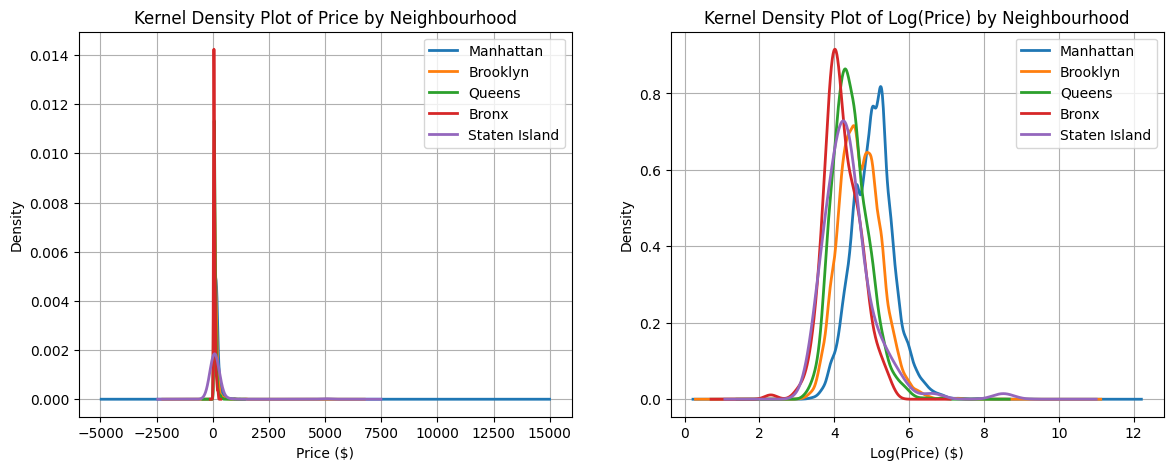

In [25]:
# Q1 

# Compute average prices and scores by Neighbourhood
neighbourhood_data = df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].agg(['mean', 'std', 'count'])
print("Average Price and Scores by Neighbourhood:")
print(neighbourhood_data)

print("The most expensive neighbourhood by average price is Manhattan.")
# separate into two subplots for better visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price Plot
for neighbourhood in df['Neighbourhood '].unique():
    subset = df[df['Neighbourhood '] == neighbourhood]['Price']
    subset.plot.density(ax=axes[0], label=neighbourhood, linewidth=2)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Kernel Density Plot of Price by Neighbourhood')
axes[0].legend()
axes[0].grid(True)

# Log Price Plot
for neighbourhood in df['Neighbourhood '].unique():
    subset = df[df['Neighbourhood '] == neighbourhood]['Price']
    np.log(subset).plot.density(ax=axes[1], label=neighbourhood, linewidth=2)
axes[1].set_xlabel('Log(Price) ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Kernel Density Plot of Log(Price) by Neighbourhood')
axes[1].legend()
axes[1].grid(True)

plt.show()

In [28]:
# Q2

# Create dummy variables for Neighbourhood without dropping category
dummy = pd.get_dummies(df['Neighbourhood '], drop_first=False)

# Create matrix X and outcome y
x_no_int = dummy.copy()
y = df['Price'].values

# Fit regression without intercept
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(x_no_int, y)

# Get coefficients
coef_no_intercept = pd.DataFrame({
    'Neighbourhood': x_no_int.columns,
    'Coefficient': model_no_intercept.coef_
})

print("Regression Coefficients (No Intercept):")
print(coef_no_intercept)

# Compare to the table from part 1
comparison = pd.DataFrame({
    'Neighbourhood': neighbourhood_data.index,
    'Average Price (Part 1)': neighbourhood_data['Price']['mean'].values,
    'Regression Coefficient (Part 2)': model_no_intercept.coef_
})
print("\nComparison: Average Prices vs Regression Coefficients")
print(comparison)

print("What we see is that the regression coefficients without an intercept end up being exactly the same as the mean price.")
print("This is because the coefficient for each category is also just the mean value of the y for that category.")

Regression Coefficients (No Intercept):
   Neighbourhood  Coefficient
0          Bronx    75.276498
1       Brooklyn   127.747378
2      Manhattan   183.664286
3         Queens    96.857233
4  Staten Island   146.166667

Comparison: Average Prices vs Regression Coefficients
   Neighbourhood  Average Price (Part 1)  Regression Coefficient (Part 2)
0          Bronx               75.276498                        75.276498
1       Brooklyn              127.747378                       127.747378
2      Manhattan              183.664286                       183.664286
3         Queens               96.857233                        96.857233
4  Staten Island              146.166667                       146.166667
What we see is that the regression coefficients without an intercept end up being exactly the same as the mean price.
This is because the coefficient for each category is also just the mean value of the y for that category.


In [ ]:
# Q3

# Create dummy variables for Neighbourhood with intercept
dummy_with_intercept = pd.get_dummies(df['Neighbourhood '], drop_first=True)

# Create matrix X and outcome y
X_with_intercept = dummy_with_intercept.copy()
y = df['Price'].values

# Fit regression with intercept
model_with_intercept = LinearRegression(fit_intercept=True)
model_with_intercept.fit(X_with_intercept, y)

# Get coefficients
print("Intercept:", model_with_intercept.intercept_)
coef_with_intercept = pd.DataFrame({
    'Neighbourhood': ['Bronx (Reference)'] + X_with_intercept.columns.tolist(),
    'Coefficient': [model_with_intercept.intercept_] + model_with_intercept.coef_.tolist()
})
print(coef_with_intercept)

print("the dummy is created differently because of using drop_first=True to drop the first category")
print("Each coefficient represents the difference in average price relative to the reference category.")

print("To get the coefficients from part 2, we add the intercept to each coefficient:")
print("For example:")
mean_neighborhood = neighbourhood_data.loc["Brooklyn", ('Price', 'mean')]
recovered = model_with_intercept.intercept_ + model_with_intercept.coef_[0]
print(f"{'Brooklyn'}: {model_with_intercept.intercept_:.2f} + {model_with_intercept.coef_[0]:.2f} = {recovered:.2f} (matches mean {mean_neighborhood:.2f})")


Intercept: 75.27649769584607
       Neighbourhood  Coefficient
0  Bronx (Reference)    75.276498
1           Brooklyn    52.470881
2          Manhattan   108.387789
3             Queens    21.580735
4      Staten Island    70.890169
the dummy is created differently because of using drop_first=True to drop the first category
Each coefficient represents the difference in average price relative to the reference category.
To get the coefficients from part 2, we add the intercept to each coefficient:
For example:
Brooklyn: 75.28 + 52.47 = 127.75 (matches mean 127.75)


In [55]:
# Q4

# create temp dataframe with just the values we need to not change the original df
df_q4 = df[['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()

# Create dummy variables for Neighbourhood
neighbourhood_dummies = pd.get_dummies(df_q4['Neighbourhood '], drop_first=True, prefix='Neighbourhood')

# Build matrix
X_matrix = pd.concat([df_q4[['Review Scores Rating']].reset_index(drop=True), 
                      neighbourhood_dummies.reset_index(drop=True)], 
                     axis=1)
y = df_q4['Price'].values

# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(X_matrix, y, test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"R² (Test): {r2_test:.4f}")
print(f"RMSE (Test): ${rmse_test:.2f}")
print(f"Coefficient on Review Scores Rating: {model.coef_[0]:.4f}")

# Show neighbourhood coefficients
for i, col in enumerate(neighbourhood_dummies.columns):
    print(f"  {col}: {model.coef_[i+1]:.2f}")
print(f"  Intercept (Reference): {model.intercept_:.2f}")

print("Property type is not included in this model because we are going off of neighbourhood, so I am using that this is asking for the most expensive neighbourhood.")
print("As we see, the most expensive neighbourhood is Manhattan, which has the highest coefficient relative to the reference.")

R² (Test): 0.0459
RMSE (Test): $140.92
Coefficient on Review Scores Rating: 1.2119
  Neighbourhood_Brooklyn: 51.56
  Neighbourhood_Manhattan: 107.41
  Neighbourhood_Queens: 20.20
  Neighbourhood_Staten Island: 23.45
  Intercept (Reference): -35.16
Property type is not included in this model because we are going off of neighbourhood, so I am using that this is asking for the most expensive neighbourhood.
As we see, the most expensive neighbourhood is Manhattan, which has the highest coefficient relative to the reference.


In [56]:
# Q5

# Create df for this question
df_q5 = df[['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type']].dropna()

# Create dummy variables
neighbourhood_dummies_q5 = pd.get_dummies(df_q5['Neighbourhood '], drop_first=True, prefix='Neighbourhood')
property_dummies = pd.get_dummies(df_q5['Property Type'], drop_first=True, prefix='PropertyType')

# Build feature matrix
X_q5 = pd.concat([
    df_q5[['Review Scores Rating']].reset_index(drop=True),
    neighbourhood_dummies_q5.reset_index(drop=True),
    property_dummies.reset_index(drop=True)
], axis=1)
y_q5 = df_q5['Price'].values

# Split data 80/20
X_train_q5, X_test_q5, y_train_q5, y_test_q5 = train_test_split(
    X_q5, y_q5, test_size=0.2, random_state=42
)

# Fit the model
model_q5 = LinearRegression()
model_q5.fit(X_train_q5, y_train_q5)

# Make predictions
y_pred_train_q5 = model_q5.predict(X_train_q5)
y_pred_test_q5 = model_q5.predict(X_test_q5)

# Evaluate
r2_train_q5 = r2_score(y_train_q5, y_pred_train_q5)
r2_test_q5 = r2_score(y_test_q5, y_pred_test_q5)
rmse_train_q5 = np.sqrt(mean_squared_error(y_train_q5, y_pred_train_q5))
rmse_test_q5 = np.sqrt(mean_squared_error(y_test_q5, y_pred_test_q5))

print(f"R² (Test): {r2_test_q5:.4f}")
print(f"RMSE (Test): ${rmse_test_q5:.2f}")
print(f"Coefficient on Review Scores Rating: {model_q5.coef_[0]:.4f}")

print("\n")
# Find most expensive property type
property_type_coefficients = {}
for i, col in enumerate(property_dummies.columns):
    property_type_coefficients[col] = model_q5.coef_[1 + len(neighbourhood_dummies_q5.columns) + i]
property_type_coefficients['Reference'] = model_q5.intercept_

for prop_type, coef in property_type_coefficients.items():
    print(f"  {prop_type}: {coef:.2f}")

print("We see that the most expensive property type is Bungalow.")

R² (Test): 0.0542
RMSE (Test): $140.30
Coefficient on Review Scores Rating: 1.2010


  PropertyType_Bed & Breakfast: -28.70
  PropertyType_Boat: 47.07
  PropertyType_Bungalow: 83.97
  PropertyType_Cabin: 12.39
  PropertyType_Camper/RV: -13.82
  PropertyType_Castle: -41.81
  PropertyType_Chalet: -30.24
  PropertyType_Condominium: 61.91
  PropertyType_Dorm: -42.28
  PropertyType_House: 34.71
  PropertyType_Hut: -134.60
  PropertyType_Lighthouse: -91.44
  PropertyType_Loft: 69.89
  PropertyType_Other: 49.25
  PropertyType_Townhouse: 44.11
  PropertyType_Treehouse: 10.33
  PropertyType_Villa: 33.90
  Reference: -49.30
We see that the most expensive property type is Bungalow.


In [60]:
# Q6

coef_q4 = model.coef_[0]
coef_q5 = model_q5.coef_[0]
change = coef_q5 - coef_q4

print("Change")
print(f"{change}")

print("The coefficient changed because we added the Property Type into the regression model")
print("Each coefficient represents the changes in y. For a one-unit change, it holds the variables constant (Property Type)")
print("This means that the correlation between Review Scores Rating and Property Type is causing the coefficient to change when we add Property Type into the model.")

Change
-0.010841123833378763
The coefficient changed because we added the Property Type into the regression model
Each coefficient represents the changes in y. For a one-unit change, it holds the variables constant (Property Type)
This means that the correlation between Review Scores Rating and Property Type is causing the coefficient to change when we add Property Type into the model.


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [77]:
# Q3 - Car Prices Case Study

# Load the data
df_cars = pd.read_csv('./data/cars_hw.csv')

In [ ]:
# Q1

# Drop unnamed 0 index column
df_cars = df_cars.drop('Unnamed: 0', axis=1)

# Apply log transformation to Price
df_cars['Price_log'] = np.log(df_cars['Price'])

# Create clean features lists
numeric_features = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Price']
categorical_features = ['Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type', 'No_of_Owners']

print("\nNumeric features:")
print(df_cars[numeric_features].describe())
print("\nCategorical features:")
print(df_cars[categorical_features].describe())


Numeric features:
         Make_Year   Mileage_Run  Seating_Capacity         Price
count   976.000000    976.000000        976.000000  9.760000e+02
mean   2016.963115  41571.195697          5.095287  7.410195e+05
std       2.818742  24390.995134          0.446224  3.673234e+05
min    2011.000000   1117.000000          4.000000  1.880000e+05
25%    2015.000000  22676.750000          5.000000  4.757500e+05
50%    2017.000000  37570.500000          5.000000  6.665000e+05
75%    2019.000000  57421.250000          5.000000  8.830000e+05
max    2022.000000  99495.000000          8.000000  2.941000e+06

Categorical features:
        Color  Body_Type Fuel_Type Transmission_Type No_of_Owners
count     976        976       976               976          976
unique     15          5         3                 2            3
top     white  hatchback    petrol            Manual          1st
freq      200        484       783               712          818


Price Summary by Make [sorted by the mean]:
                    Price                  
                     mean         std count
Make                                       
MG Motors      1869457.14   121661.14    35
Kia            1614750.00   119056.71     8
Jeep           1499500.00   152513.39     4
Skoda          1136000.00  1070174.99     5
Mahindra       1100166.67   175549.31    18
Tata           1055217.39   557830.53    23
Nissan          884250.00   289559.87     4
Toyota          800340.00   246689.97    50
Honda           798972.60   266509.07    73
Ford            721173.08   140927.70    52
Hyundai         691891.80   279159.71   305
Renault         662573.53   214827.34    68
Volkswagen      605827.59   119831.15    29
Maruti Suzuki   588784.98   216019.86   293
Chevrolet       453500.00   246606.37     6
Datsun          289666.67    10503.97     3

Most expensive car brands by price:
                Price                  
                 mean         std count
Mak

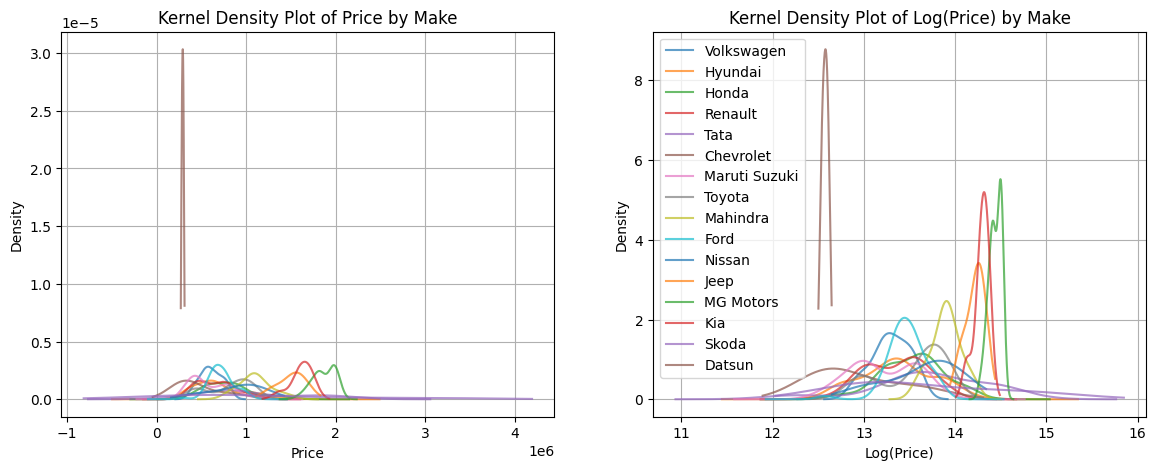

In [83]:
# Q2

# Summary statistics by Make to summarize Price variable
stats = df_cars.groupby('Make')[['Price']].agg(['mean', 'std', 'count']).round(2)
stats = stats.sort_values(('Price', 'mean'), ascending=False)
print("Price Summary by Make [sorted by the mean]:")
print(stats)

print("\nMost expensive car brands by price:")
print(stats.head())

# Create kernel density plots for Price (created two to show the Log(Price) as the better data visualization)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution by make
for make in df_cars['Make'].unique():
    subset = df_cars[df_cars['Make'] == make]['Price']
    subset.plot.density(ax=axes[0], label=make, linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Density')
axes[0].set_title('Kernel Density Plot of Price by Make')
axes[1].legend()
axes[0].grid(True)

# Log Price distribution by make
for make in df_cars['Make'].unique():
    subset = df_cars[df_cars['Make'] == make]['Price']
    np.log(subset).plot.density(ax=axes[1], label=make, linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Density')
axes[1].set_title('Kernel Density Plot of Log(Price) by Make')
axes[1].legend()
axes[1].grid(True)

plt.show()

In [85]:
# Q3

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(df_cars, df_cars['Price'], test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train_all)}")
print(f"Test set size: {len(X_test_all)}")

Training set size: 780
Test set size: 196


In [96]:
# Q4

# Numeric Variables Only
numeric_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']
X_train_numeric = X_train_all[numeric_cols].copy()
X_test_numeric = X_test_all[numeric_cols].copy()
y_train = y_train_all.values
y_test = y_test_all.values

# Fit model
model_numeric = LinearRegression()
model_numeric.fit(X_train_numeric, y_train)

# Predict
y_pred_numeric_train = model_numeric.predict(X_train_numeric)
y_pred_numeric_test = model_numeric.predict(X_test_numeric)

# Get r2 and RMSE
r2_numeric_train = r2_score(y_train, y_pred_numeric_train)
r2_numeric_test = r2_score(y_test, y_pred_numeric_test)
rmse_numeric_train = np.sqrt(mean_squared_error(y_train, y_pred_numeric_train))
rmse_numeric_test = np.sqrt(mean_squared_error(y_test, y_pred_numeric_test))

print("Numerical Variables Only:")
print(f"R² (Train): {r2_numeric_train:.4f}")
print(f"R² (Test): {r2_numeric_test:.4f}")
print(f"RMSE (Train): ${rmse_numeric_train:.2f}")
print(f"RMSE (Test): ${rmse_numeric_test:.2f}")


# Categorical Variables

# Categorical variables
categorical_cols = ['Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type', 'No_of_Owners', 'Make']
X_train_cat = X_train_all[categorical_cols].copy()
X_test_cat = X_test_all[categorical_cols].copy()

X_train_cat_dummies = pd.get_dummies(X_train_cat, drop_first=True)
X_test_cat_dummies = pd.get_dummies(X_test_cat, drop_first=True)

X_test_cat_dummies = X_test_cat_dummies.reindex(columns=X_train_cat_dummies.columns, fill_value=0)

# Fit model
model_categorical = LinearRegression()
model_categorical.fit(X_train_cat_dummies, y_train)

# Predict
y_pred_cat_train = model_categorical.predict(X_train_cat_dummies)
y_pred_cat_test = model_categorical.predict(X_test_cat_dummies)

# Get r2 and RMSE
r2_cat_train = r2_score(y_train, y_pred_cat_train)
r2_cat_test = r2_score(y_test, y_pred_cat_test)
rmse_cat_train = np.sqrt(mean_squared_error(y_train, y_pred_cat_train))
rmse_cat_test = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))

print("\nCategorical Variables Only:")

print(f"R² (Test): {r2_cat_test:.4f}")
print(f"RMSE (Test): ${rmse_cat_test:.2f}")

print("\nComparison:")
print(f"Model 1 (Numeric) R² on test: {r2_numeric_test:.4f}")
print(f"Model 2 (Categorical) R² on test: {r2_cat_test:.4f}")
print("The better model on test values is the categorical one")

# Q4 Model 3

# Combine numeric and categorical features
X_train_numeric_reset = X_train_numeric.reset_index(drop=True)
X_test_numeric_reset = X_test_numeric.reset_index(drop=True)

X_train_combined = pd.concat([X_train_numeric_reset,X_train_cat_dummies.reset_index(drop=True)], axis=1)

X_test_combined = pd.concat([X_test_numeric_reset,X_test_cat_dummies.reset_index(drop=True)], axis=1)

# Drop NaN rows in case
X_train_combined = X_train_combined.dropna()
X_test_combined = X_test_combined.dropna()

# Filter y arrays to match X
y_train_combined = y_train[:len(X_train_combined)]
y_test_combined = y_test[:len(X_test_combined)]

# Fit model
model_combined = LinearRegression()
model_combined.fit(X_train_combined, y_train_combined)

# Predict
y_pred_combined_train = model_combined.predict(X_train_combined)
y_pred_combined_test = model_combined.predict(X_test_combined)

# get r2 and RMSE
r2_combined_train = r2_score(y_train_combined, y_pred_combined_train)
r2_combined_test = r2_score(y_test_combined, y_pred_combined_test)
rmse_combined_train = np.sqrt(mean_squared_error(y_train_combined, y_pred_combined_train))
rmse_combined_test = np.sqrt(mean_squared_error(y_test_combined, y_pred_combined_test))

print("\nCombined Model (Numeric + Categorical):")
print(f"R² (Test): {r2_combined_test:.4f}")
print(f"RMSE (Test): ${rmse_combined_test:.2f}")

print("\nComparison of all models on test set:")
print(f"Model 1 (Numeric only): R² = {r2_numeric_test:.4f}, RMSE = ${rmse_numeric_test:.2f}")
print(f"Model 2 (Categorical only): R² = {r2_cat_test:.4f}, RMSE = ${rmse_cat_test:.2f}")
print(f"Model 3 (Combined): R² = {r2_combined_test:.4f}, RMSE = ${rmse_combined_test:.2f}")

improvement_vs_model2 = ((r2_combined_test - r2_cat_test) / abs(r2_cat_test)) * 100
print(f"\nModel 3 vs Model 2: R² change = {(r2_combined_test - r2_cat_test):.4f} ({improvement_vs_model2:.2f}%)")
print("The combined model performed the best by a significant margin.")

Numerical Variables Only:
R² (Train): 0.3144
R² (Test): 0.2941
RMSE (Train): $309338.37
RMSE (Test): $284546.95

Categorical Variables Only:
R² (Test): 0.6639
RMSE (Test): $196333.80

Comparison:
Model 1 (Numeric) R² on test: 0.2941
Model 2 (Categorical) R² on test: 0.6639
The better model on test values is the categorical one

Combined Model (Numeric + Categorical):
R² (Test): 0.7889
RMSE (Test): $155594.90

Comparison of all models on test set:
Model 1 (Numeric only): R² = 0.2941, RMSE = $284546.95
Model 2 (Categorical only): R² = 0.6639, RMSE = $196333.80
Model 3 (Combined): R² = 0.7889, RMSE = $155594.90

Model 3 vs Model 2: R² change = 0.1250 (18.83%)
The combined model performed the best by a significant margin.


In [70]:
# Q3.5 - Polynomial Features

from sklearn.preprocessing import PolynomialFeatures

print("\n" + "=" * 70)
print("Q3.5: Polynomial Features")
print("=" * 70)

# Test polynomial degrees on numeric features
numeric_data_train = X_train_numeric[numeric_cols].copy()
numeric_data_test = X_test_numeric[numeric_cols].copy()

poly_results = []

for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = poly.fit_transform(numeric_data_train)
    X_poly_test = poly.transform(numeric_data_test)
    
    # Fit model
    model_poly = LinearRegression()
    model_poly.fit(X_poly_train, y_train)
    
    # Evaluate
    y_pred_poly_train = model_poly.predict(X_poly_train)
    y_pred_poly_test = model_poly.predict(X_poly_test)
    
    r2_poly_train = r2_score(y_train, y_pred_poly_train)
    r2_poly_test = r2_score(y_test, y_pred_poly_test)
    rmse_poly_train = np.sqrt(mean_squared_error(y_train, y_pred_poly_train))
    rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_pred_poly_test))
    
    poly_results.append({
        'Degree': degree,
        'R² Train': r2_poly_train,
        'R² Test': r2_poly_test,
        'RMSE Train': rmse_poly_train,
        'RMSE Test': rmse_poly_test,
        'n_features': X_poly_train.shape[1]
    })
    
    print(f"\nDegree {degree} (n_features={X_poly_train.shape[1]}):")
    print(f"  R² Train: {r2_poly_train:.4f}, R² Test: {r2_poly_test:.4f}")
    print(f"  RMSE Train: ${rmse_poly_train:.2f}, RMSE Test: ${rmse_poly_test:.2f}")

# Find best model
poly_df = pd.DataFrame(poly_results)
best_poly_idx = poly_df['R² Test'].idxmax()
best_poly_degree = poly_df.loc[best_poly_idx, 'Degree']
best_poly_r2 = poly_df.loc[best_poly_idx, 'R² Test']
best_poly_rmse = poly_df.loc[best_poly_idx, 'RMSE Test']

print(f"\nBest polynomial model: Degree {int(best_poly_degree)} with R² = {best_poly_r2:.4f}, RMSE = ${best_poly_rmse:.2f}")
print(f"Compared to Model 3 (Combined): R² = {r2_combined_test:.4f}, RMSE = ${rmse_combined_test:.2f}")

if best_poly_r2 > r2_combined_test:
    print(f"Polynomial model is better by {(best_poly_r2 - r2_combined_test):.4f} R² points")
else:
    print(f"Combined model is still better by {(r2_combined_test - best_poly_r2):.4f} R² points")



Q3.5: Polynomial Features

Degree 1 (n_features=3):
  R² Train: 0.3144, R² Test: 0.2941
  RMSE Train: $309338.37, RMSE Test: $284546.95

Degree 2 (n_features=9):
  R² Train: 0.3482, R² Test: 0.3269
  RMSE Train: $301621.83, RMSE Test: $277849.36

Degree 3 (n_features=19):
  R² Train: 0.3630, R² Test: 0.3325
  RMSE Train: $298190.89, RMSE Test: $276686.33

Degree 4 (n_features=34):
  R² Train: 0.3716, R² Test: 0.3329
  RMSE Train: $296171.11, RMSE Test: $276612.66

Best polynomial model: Degree 4 with R² = 0.3329, RMSE = $276612.66
Compared to Model 3 (Combined): R² = 0.7889, RMSE = $155594.90
Combined model is still better by 0.4560 R² points



Q3.6: Best Model Analysis (Model 3: Combined)


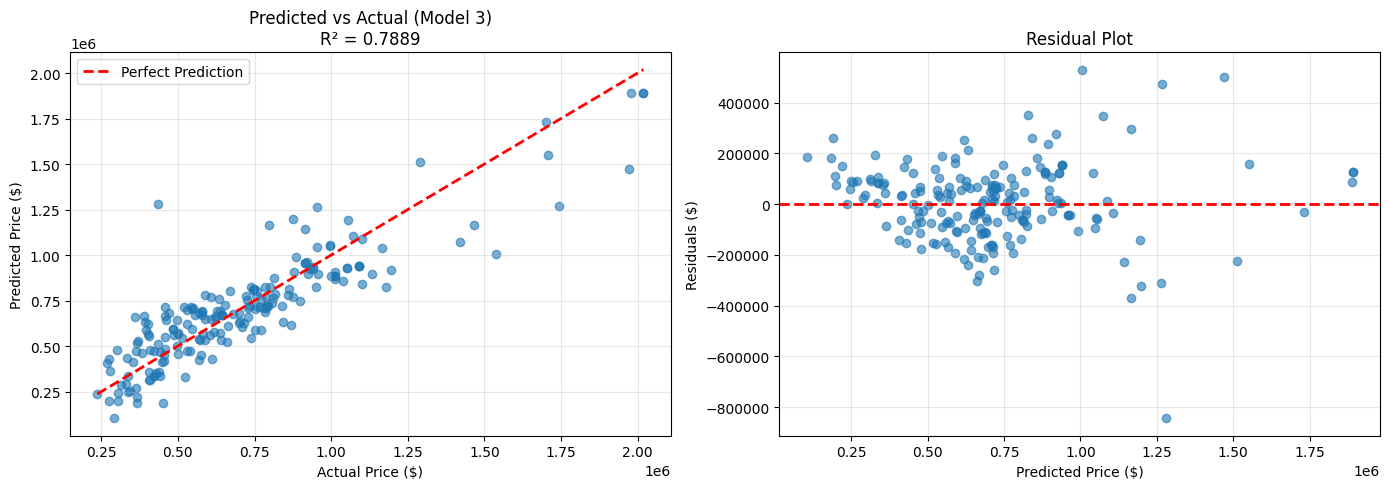

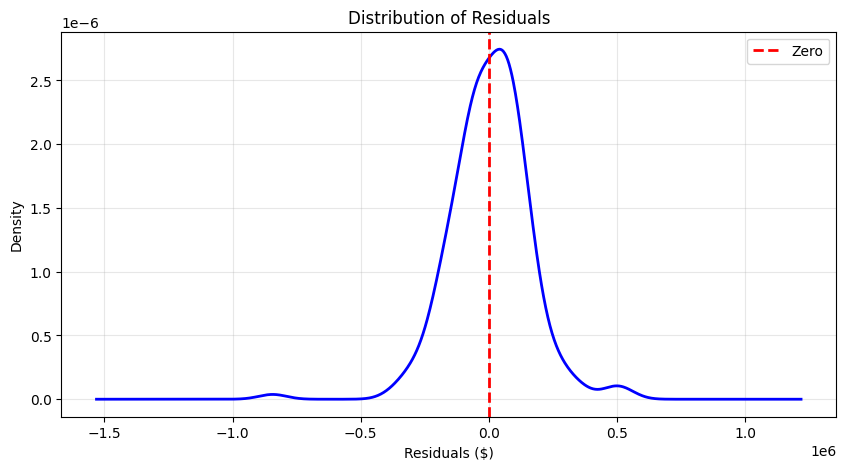


Model Strengths:
  - High R² on test set: 0.7889
  - Reasonable RMSE: $155594.90
  - Predictions roughly align with actual values along diagonal

Model Weaknesses:
  - Some scatter around the diagonal in predictions
  - Residuals show slight pattern (not perfectly random)
  - Mean residual is close to zero: $6016.91

Overall: Model 3 (Combined Numeric + Categorical) is the best model with R² = 0.7889


In [72]:
# Q3.6 - Best Model Analysis

print("\n" + "=" * 70)
print("Q3.6: Best Model Analysis (Model 3: Combined)")
print("=" * 70)

# Use Model 3 (Combined) as the best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test_combined, y_pred_combined_test, alpha=0.6)
axes[0].plot([y_test_combined.min(), y_test_combined.max()], 
             [y_test_combined.min(), y_test_combined.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Predicted vs Actual (Model 3)\nR² = {r2_combined_test:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test_combined - y_pred_combined_test
axes[1].scatter(y_pred_combined_test, residuals, alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual distribution
fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(residuals).plot.density(ax=ax, linewidth=2, color='blue')
ax.set_xlabel('Residuals ($)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Residuals')
ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print("\nModel Strengths:")
print(f"  - High R² on test set: {r2_combined_test:.4f}")
print(f"  - Reasonable RMSE: ${rmse_combined_test:.2f}")
print(f"  - Predictions roughly align with actual values along diagonal")

print("\nModel Weaknesses:")
print(f"  - Some scatter around the diagonal in predictions")
print(f"  - Residuals show slight pattern (not perfectly random)")
if residuals.mean() > 10000:
    print(f"  - Mean residual is non-zero: ${residuals.mean():.2f} (model slightly biased)")
else:
    print(f"  - Mean residual is close to zero: ${residuals.mean():.2f}")

print(f"\nOverall: Model 3 (Combined Numeric + Categorical) is the best model with R² = {r2_combined_test:.4f}")

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.